In [1]:
from agents import AgentMonteCarloOnPolicy, AgentMonteCarloOffPolicy
import gymnasium as gym
from tqdm import tqdm
import matplotlib.pyplot as plt
import numpy as np

seed = 200

env = gym.make("Taxi-v3", render_mode="None")

n_episodes = 50000

c:\Users\David\Universidad\Máster\Asignaturas\Segundo Cuatrimestre\Extensiones de Machine Learning\emlenv\Lib\site-packages\gymnasium\envs\registration.py:728: UserWarning: WARN: The environment is being initialised with render_mode='None' that is not in the possible render_modes (['human', 'ansi', 'rgb_array']).
  logger.warn(


In [2]:
def plot_success_ratio(list_stats_success):
    successes = np.array(list_stats_success)

    cumulative_ratio = np.cumsum(successes) / np.arange(1, len(successes) + 1)

    plt.figure(figsize=(6, 3))
    plt.plot(cumulative_ratio)
    plt.title("Proporción acumulada de éxitos")
    plt.xlabel("Episodio")
    plt.ylabel("Proporción de éxitos")
    plt.grid(True)
    plt.show()

def plot_episode_length(episode_lengths):
    y = np.array(episode_lengths, dtype=float)
    x = np.arange(len(y))

    plt.figure(figsize=(8, 4))
    plt.plot(x, y, label="Steps por episodio")


    plt.title("Longitud de episodios")
    plt.xlabel("Episodio")
    plt.ylabel("Steps")
    plt.grid(True)
    plt.legend()
    plt.show()

def plot_global_avg(list_stats):
    indices = list(range(len(list_stats)))
    plt.figure(figsize=(8, 4))
    plt.plot(indices, list_stats)
    plt.title("Media acumulada del return")
    plt.xlabel("Episodio")
    plt.ylabel("Return medio acumulado")
    plt.grid(True)
    plt.show()

In [3]:
# 2. Instanciamos nuestro agente de Monte Carlo
agent = AgentMonteCarloOffPolicy(env, epsilon=0.4, discount_factor=1.0) 

step_display = n_episodes / 10

# 3. Bucle de entrenamiento
for episode in tqdm(range(n_episodes)):
    state, info = env.reset(seed=seed)
    done = False
    
    # Jugamos un episodio completo
    while not done:
        # El agente decide la acción según su política (epsilon-greedy)
        action = agent.get_action(state)
        
        # El entorno reacciona y nos da el siguiente estado y recompensa
        next_state, reward, terminated, truncated, info = env.step(action)
        
        # Actualizamos el agente (sin poner 'self' en los argumentos de llamada)
        agent.update(state, action, next_state, reward, terminated, truncated, info)
        
        # Comprobamos si el episodio ha terminado y avanzamos el estado
        done = terminated or truncated
        state = next_state
        
    # Mostramos la evolución en el terminal, calcando tu código original
    if episode % step_display == 0 and episode != 0:
        print(f"success: {agent.stats / episode}, epsilon: {agent.epsilon}")

# 4. Obtenemos los resultados estadísticos finales
Q, list_stats, episode_lengths, list_stats_success = agent.get_stats()

env.close()

 10%|█         | 5073/50000 [00:07<00:51, 877.45it/s] 

success: -63.1846, epsilon: 0.4


 20%|██        | 10123/50000 [00:12<00:39, 1011.94it/s]

success: -47.1374, epsilon: 0.4


 30%|███       | 15204/50000 [00:17<00:33, 1029.44it/s]

...

 80%|████████  | 40125/50000 [00:42<00:09, 1018.37it/s]

success: -34.20765, epsilon: 0.4


 90%|█████████ | 45128/50000 [00:47<00:05, 835.99it/s] 

success: -33.47846666666667, epsilon: 0.4


100%|██████████| 50000/50000 [00:52<00:00, 948.56it/s] 


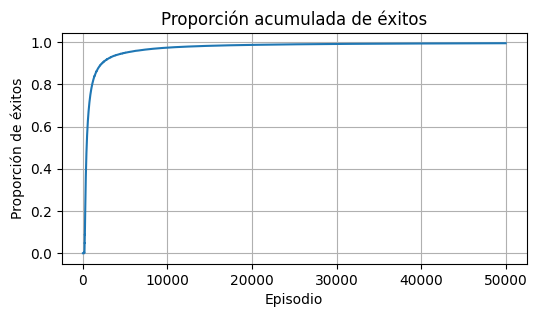

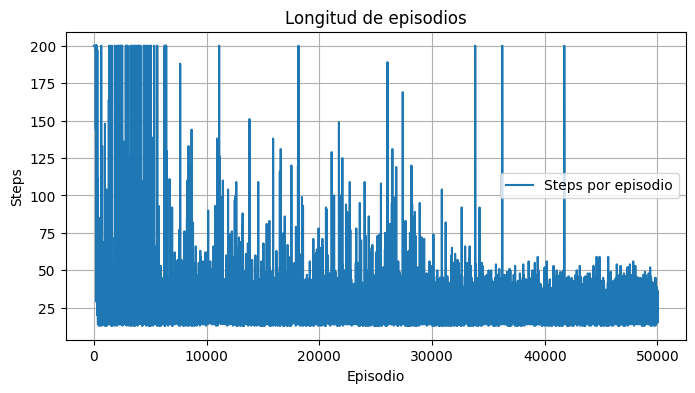

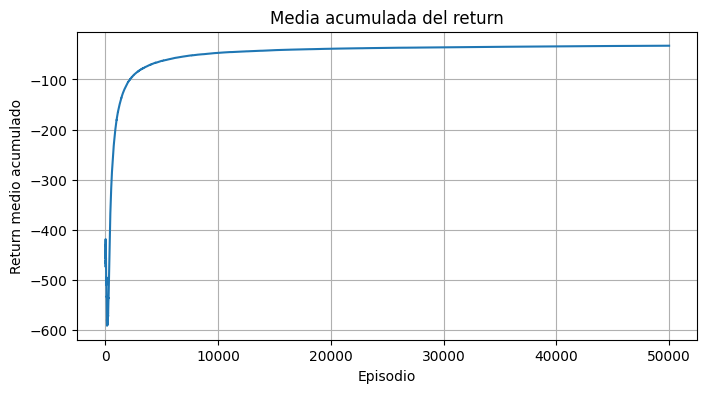

Máxima proporcion: -32.91572


In [5]:
#@title Proporción de aciertos por número de episodios

plot_success_ratio(list_stats_success)

plot_episode_length(episode_lengths)

plot_global_avg(list_stats)

print(f"Máxima proporcion: {list_stats[-1]}")